# Lecture 1 — Practical: *Meeting Your Transcriptomic Dataset*
### Practical Machine Learning for Transcriptomics in Cancer Research

**No modelling today.** The whole point of this session is to *know your data before you trust it*.
You will load a real transcriptomic dataset, audit its clinical metadata, define a clean label,
measure class balance, run PCA, discover a batch effect, and build a defensible
train / validation / test split.

Adopt the mindset of an analyst writing the **"data sanity"** section of a methods paper — not
someone racing to a result. Every decision you make should be **written down** as you go.

---

#### The data (real cohorts)

| Cohort | Platform | Role | Source |
|---|---|---|---|
| **METABRIC** (~1,900 tumours) | Illumina HT-12 | primary cohort, long-term survival follow-up | cBioPortal `brca_metabric` |
| **GSE6532** (Loi et al.) | Affymetrix | second platform — combined in **deliberately** | NCBI GEO |

We predict **recurrence** (a relapse / DMFS-style **binary** endpoint). METABRIC has **no pCR** —
that's expected, and is itself a teaching point about letting the data choose the endpoint.

> **Why combine two cohorts on two platforms?** Because that is exactly where a real **batch
> effect** is born — and Section 4 is about discovering it. This is a *constructed teaching
> example*, not how you would assemble a genuine validation set.

> **Network note.** These cells download real data from cBioPortal and GEO. You need internet
> access. Downloads are cached to the lesson's `practical/task/datasets/` folder (resolved
> automatically), so you only fetch once. The data files are **git-ignored** — they are not
> committed to the repository; re-running this notebook re-fetches them on demand.


## Section 0 — Setup & framing  *(≈10 min)*

First, install/import what we need and create a cache directory.


In [1]:
# Core scientific stack (usually preinstalled). GEOparse fetches GSE6532 from GEO.
# Run once; safe to re-run.
import sys, subprocess
def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

try:
    import GEOparse  # noqa
except ImportError:
    _pip("GEOparse")

import os, tarfile, io, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
np.random.seed(0)          # reproducibility for the splits later

def _resolve_data_dir():
    """Find the lesson's practical/task/datasets/ folder regardless of where Jupyter
    was launched (the student notebook runs from notebooks/, the solution from
    solutions/lesson01_biological_question/notebooks/ — both should share ONE cache).

    Repo layout this targets:
      lessons/lesson01_biological_question/practical/task/
        ├── notebooks/   <- student notebook usually runs from here
        └── datasets/    <- data is cached here (git-ignored, kept via .gitkeep)
    """
    here = Path.cwd()
    # 1) PRIORITY: walk upward to the repo root, then locate the lesson-01 datasets anchor
    #    by glob (robust to the exact topic suffix), so the student and solution notebooks
    #    share the same cache.
    for parent in [here, *here.parents]:
        lessons = parent / "lessons"
        if lessons.is_dir():
            for cand in sorted(lessons.glob("lesson01_*/practical/task/datasets")):
                cand.mkdir(parents=True, exist_ok=True)
                return cand
            # lessons/ exists but no datasets dir yet -> create the canonical one if the
            # lesson folder is present
            for cand in sorted(lessons.glob("lesson01_*/practical/task")):
                d = cand / "datasets"; d.mkdir(parents=True, exist_ok=True)
                return d
    # 2) Otherwise, try datasets next to / beside the notebook.
    for c in [here.parent / "datasets", here / "datasets"]:
        if c.parent.exists():
            c.mkdir(parents=True, exist_ok=True)
            return c
    # 3) Last resort.
    fallback = here / "datasets"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback

DATA_DIR = str(_resolve_data_dir())
print("Setup complete. Data will be cached in:")
print("  ", os.path.abspath(DATA_DIR))
print("(Large downloads are git-ignored; the folder is kept via .gitkeep.)")

Setup complete. Data will be cached in:
   /beegfs/scratch/ieo7993/projects/ml26/lessons/lesson01_biological_question/practical/task/datasets
(Large downloads are git-ignored; the folder is kept via .gitkeep.)


### The prediction task (write it in your own words)

Before touching any code, state the prediction task **precisely**. A well-posed task names four
things: the **input**, the **output (label)**, **when** each is measured, and **on whom**.

> **Exercise 0.1 — edit the markdown below and commit your task statement.**


**My task statement (worked example):**

- **Input (X):** pre-surgery / baseline tumour gene-expression profile (~20,000 genes) per patient.
- **Output (y):** a *binary recurrence* label — did the patient relapse within a fixed horizon
  (e.g. 5 years) of surgery, among patients with adequate follow-up?
- **When:** expression is measured once on the resected/biopsy tumour; the outcome is observed
  over years of clinical follow-up.
- **On whom:** patients with **HR+/HER2−** early breast cancer.

The model would ultimately help decide who is at high enough recurrence risk to consider
treatment escalation — and who can be spared it.


---
## Data loaders (shared infrastructure)

The two functions below fetch the **real** cohorts and cache them. Read them, but you don't need
to edit them — the teaching happens *after* the data is loaded. Each returns a tidy
`(expression, clinical)` pair where **expression is genes × samples** (the bioinformatics
convention — you will fix the orientation yourself in Section 1).


In [2]:
# Data loaders. METABRIC comes from the cBioPortal datahub (now served as individual
# files via GitHub LFS); GSE6532 comes from NCBI GEO over HTTPS. Run once; cached after.
CBIO_BASE = ("https://media.githubusercontent.com/media/cBioPortal/datahub/"
             "master/public/brca_metabric")
CBIO_FILES = {
    "expr":    "data_mrna_illumina_microarray.txt",   # large (~660 MB)
    "patient": "data_clinical_patient.txt",
    "sample":  "data_clinical_sample.txt",
}

def _download(url, dest):
    """Stream a URL to dest, skipping the download if a non-empty cache exists."""
    if os.path.exists(dest) and os.path.getsize(dest) > 0:
        return dest
    print(f"Downloading {os.path.basename(dest)} ...")
    r = requests.get(url, stream=True, timeout=300, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    with open(dest, "wb") as fh:
        for chunk in r.iter_content(chunk_size=1 << 20):
            fh.write(chunk)
    return dest

def _read_cbio_clinical(path):
    """cBioPortal clinical files carry 4 '#'-commented header lines above the real header."""
    return pd.read_csv(path, sep="\t", comment="#", low_memory=False)

def load_metabric(data_dir=DATA_DIR):
    """Download & parse METABRIC (brca_metabric) from the cBioPortal datahub.

    The expression file is large (~660 MB); the first run takes a few minutes, then caches.

    Returns
    -------
    expr : DataFrame  (genes x samples)  -- Illumina HT-12 microarray, log-intensity
    clin : DataFrame  (samples x clinical fields)
    """
    paths = {k: _download(f"{CBIO_BASE}/{fn}", os.path.join(data_dir, fn))
             for k, fn in CBIO_FILES.items()}
    expr = pd.read_csv(paths["expr"], sep="\t", low_memory=False)
    expr = expr.drop(columns=[c for c in ["Entrez_Gene_Id"] if c in expr.columns])
    expr = expr.dropna(subset=["Hugo_Symbol"]).set_index("Hugo_Symbol")
    expr = expr[~expr.index.duplicated(keep="first")]      # one row per gene symbol
    pat  = _read_cbio_clinical(paths["patient"])
    smp  = _read_cbio_clinical(paths["sample"])
    clin = pat.merge(smp, on="PATIENT_ID", how="inner", suffixes=("", "_smp"))
    if "SAMPLE_ID" in clin.columns:
        clin = clin.set_index("SAMPLE_ID")
    return expr, clin


GSE_SOFT_URL = ("https://ftp.ncbi.nlm.nih.gov/geo/series/GSE6nnn/GSE6532/"
                "soft/GSE6532_family.soft.gz")

def load_gse6532(data_dir=DATA_DIR):
    """Download & parse GSE6532 (Loi et al.) from GEO.

    We fetch the family SOFT file over HTTPS (more reliable than GEOparse's default FTP),
    restrict to the single most-represented Affymetrix platform, and map its probes to
    gene symbols via the platform (GPL) annotation. The result is a symbol-indexed matrix
    that shares thousands of genes with METABRIC -- the common feature space the PCA
    batch demo needs.

    Returns
    -------
    expr : DataFrame  (genes x samples)  -- Affymetrix, symbol-collapsed (mean over probes)
    clin : DataFrame  (samples x clinical fields)
    """
    import GEOparse, collections
    soft = _download(GSE_SOFT_URL, os.path.join(data_dir, "GSE6532_family.soft.gz"))
    gse  = GEOparse.get_GEO(filepath=soft, silent=True)

    plat_of = {name: gsm.metadata.get("platform_id", ["?"])[0]
               for name, gsm in gse.gsms.items()}
    dom = collections.Counter(plat_of.values()).most_common(1)[0][0]   # dominant platform

    # probe -> gene symbol from the platform annotation
    gpl = gse.gpls[dom].table
    sym_col = next((c for c in gpl.columns
                    if c.lower() in ("gene symbol", "gene_symbol", "symbol")), None)
    pmap = gpl.set_index("ID")[sym_col].dropna().astype(str)
    pmap = pmap[pmap.str.len() > 0]

    cols, meta_rows = {}, {}
    for name, gsm in gse.gsms.items():
        if plat_of[name] != dom:
            continue
        tbl = gsm.table
        if tbl is None or "VALUE" not in tbl.columns:
            continue
        cols[name] = pd.Series(tbl["VALUE"].values, index=tbl["ID_REF"].astype(str).values)
        ch = gsm.metadata.get("characteristics_ch1", [])
        row = {"title": "; ".join(gsm.metadata.get("title", []))}
        for item in ch:
            if ":" in item:
                k, v = item.split(":", 1)
                row[k.strip().lower()] = v.strip()
        meta_rows[name] = row

    expr = pd.DataFrame(cols)                        # probes x samples
    expr = expr[expr.index.isin(pmap.index)]
    expr.index = pmap.loc[expr.index].values         # probes -> gene symbols
    expr = expr.groupby(level=0).mean()              # collapse probes per gene
    clin = pd.DataFrame(meta_rows).T
    return expr, clin

print("Loaders defined: load_metabric(), load_gse6532()")

Loaders defined: load_metabric(), load_gse6532()


In [3]:
# Fetch both cohorts (cached after first run).
metabric_expr, metabric_clin = load_metabric()
print("METABRIC expression (genes x samples):", metabric_expr.shape)
print("METABRIC clinical:", metabric_clin.shape)

gse_expr, gse_clin = load_gse6532()
print("GSE6532 expression (probes x samples):", gse_expr.shape)
print("GSE6532 clinical:", gse_clin.shape)

METABRIC expression (genes x samples): (20384, 1980)
METABRIC clinical: (2509, 35)
GSE6532 expression (probes x samples): (13515, 327)
GSE6532 clinical: (327, 18)


---
## Section 1 — Loading & orienting the data  *(≈20 min)*

The loaders gave you expression as **genes × samples** (the bioinformatics convention). The ML
convention is **samples × genes** (scikit-learn expects rows = examples). Transposition errors are
a classic, embarrassing bug — so you will determine the orientation *from evidence*, then assert it.


> **Exercise 1.1 — determine orientation from evidence, then assert it.**
>
> Don't just trust the docstring. Look at the shapes and the index/columns and *reason* about which
> axis is samples and which is genes. Then transpose METABRIC to **samples × genes** and assert it.
>
> *Hints:*
> - There are ~20,000 genes but only ~1,900 samples — the long axis is genes.
> - Gene names look like `ESR1`, `MKI67`; sample IDs look like `MB-0001`.
> - After transposing, `X.shape[0]` should be the number of samples (the smaller number).


In [4]:
# Evidence: which axis is which?
print("rows (index) sample:", list(metabric_expr.index[:3]), "...")
print("cols sample:", list(metabric_expr.columns[:3]), "...")
print("shape genes x samples:", metabric_expr.shape)

# Genes are the long axis (~20k), samples the short axis (~1.9k).
# ML convention = samples x genes -> transpose.
X_metabric = metabric_expr.T.copy()
X_metabric.index.name = "SAMPLE_ID"

# Assert orientation: more genes than samples, and gene-like column names.
n_samples, n_genes = X_metabric.shape
assert n_genes > n_samples, "After transpose, columns (genes) should outnumber rows (samples)."
assert "ESR1" in X_metabric.columns, "Expected gene symbols as columns (e.g. ESR1)."
print(f"\nOriented to samples x genes: {n_samples} samples x {n_genes} genes")
print("value range:", float(np.nanmin(X_metabric.values)), "to", float(np.nanmax(X_metabric.values)))
print("missing values:", int(np.isnan(X_metabric.values).sum()))

rows (index) sample: ['RERE', 'RNF165', 'PHF7'] ...
cols sample: ['MB-0362', 'MB-0346', 'MB-0386'] ...
shape genes x samples: (20384, 1980)

Oriented to samples x genes: 1980 samples x 20384 genes
value range: 4.55791033184584 to 14.8794124402054
missing values: 16


> **Exercise 1.2 — join expression to clinical metadata, and investigate failures.**
>
> Join `X_metabric` (indexed by sample ID) to `metabric_clin` (also indexed by `SAMPLE_ID`).
> Report how many samples matched, and **look at** the ones that didn't — don't silently drop them.
>
> *Hint:* `X_metabric.index` vs `metabric_clin.index`; use set operations to see the mismatch.


In [5]:
expr_ids = set(X_metabric.index)
clin_ids = set(metabric_clin.index)
matched  = expr_ids & clin_ids
only_expr = expr_ids - clin_ids
only_clin = clin_ids - expr_ids

print(f"samples with expression:        {len(expr_ids)}")
print(f"samples with clinical:          {len(clin_ids)}")
print(f"matched (in both):              {len(matched)}")
print(f"expression only (no clinical):  {len(only_expr)}")
print(f"clinical only (no expression):  {len(only_clin)}")

# Keep only matched samples, aligned in the same order.
common = sorted(matched)
X_metabric = X_metabric.loc[common]
clin = metabric_clin.loc[common]
print("\nAfter join:", X_metabric.shape[0], "samples aligned to clinical table")

samples with expression:        1980
samples with clinical:          2509
matched (in both):              1980
expression only (no clinical):  0
clinical only (no expression):  529

After join: 1980 samples aligned to clinical table


> **Discussion 1 (write a sentence).** What real-world events cause samples to fail a join
> (relabelled IDs, withdrawn consent, QC failures, version drift)? Why is *silently* dropping
> unmatched samples dangerous for the conclusions you'll later draw?


---
## Section 2 — Auditing the clinical metadata and the label  *(≈25 min)*

METABRIC has **no pCR**. It has long-term survival follow-up, so our label is **binary recurrence**.
You must turn messy survival fields into a clean target — and **record every decision**.


First, filter to the course cohort — **HR+/HER2−** — to match the clinical question.

> **Exercise 2.0 — filter to HR+/HER2−** using the receptor-status columns, and report how many
> tumours remain.
>
> *Hint:* METABRIC clinical columns include `ER_STATUS`, `PR_STATUS`, `HER2_STATUS`
> (values like `Positive`/`Negative`). HR+ = ER **or** PR positive; HER2− = HER2 negative.


In [6]:
# Inspect candidate columns
for c in ["ER_STATUS", "PR_STATUS", "HER2_STATUS"]:
    if c in clin.columns:
        print(c, "->", clin[c].value_counts(dropna=False).to_dict())

hrpos  = (clin.get("ER_STATUS").eq("Positive")) | (clin.get("PR_STATUS").eq("Positive"))
her2neg = clin.get("HER2_STATUS").eq("Negative")
mask = (hrpos & her2neg).fillna(False)

clin = clin[mask].copy()
X_metabric = X_metabric.loc[clin.index]
print(f"\nHR+/HER2- cohort: {clin.shape[0]} tumours retained")

ER_STATUS -> {'Positive': 1506, 'Negative': 474}
PR_STATUS -> {'Positive': 1040, 'Negative': 940}
HER2_STATUS -> {'Negative': 1733, 'Positive': 247}

HR+/HER2- cohort: 1413 tumours retained


> **Exercise 2.1 — define a binary recurrence label, with an explicit censoring policy.**
>
> METABRIC exposes relapse-free survival fields (commonly `RFS_STATUS` like
> `"0:Not Recurred"` / `"1:Recurred"`, and `RFS_MONTHS`). Define:
>
> `y = 1` if the patient **recurred within the horizon** (e.g. 60 months);
> `y = 0` if the patient was **followed at least the horizon with no recurrence**;
> **exclude** patients censored *before* the horizon (we cannot know their outcome).
>
> Report how many are positive, negative, and excluded — and **write down** your horizon and
> censoring rule. *A censored patient is **not** automatically a non-event.*


In [7]:
HORIZON = 60  # months (5 years) -- a documented choice

# Locate the relapse fields (names can vary slightly across cBioPortal exports).
status_col = next((c for c in ["RFS_STATUS", "DFS_STATUS"] if c in clin.columns), None)
months_col = next((c for c in ["RFS_MONTHS", "DFS_MONTHS"] if c in clin.columns), None)
assert status_col and months_col, f"Could not find relapse fields; available: {list(clin.columns)}"
print("Using:", status_col, "and", months_col)
print(clin[status_col].value_counts(dropna=False).to_dict())

recurred = clin[status_col].astype(str).str.startswith("1")   # "1:Recurred"
months   = pd.to_numeric(clin[months_col], errors="coerce")

# Build label with explicit censoring policy
y = pd.Series(index=clin.index, dtype="float")
y[(recurred) & (months <= HORIZON)] = 1                       # recurred within horizon
y[(~recurred) & (months >= HORIZON)] = 0                      # event-free through horizon
# everyone else -> NaN -> excluded:
#   - recurred AFTER horizon (no event yet at horizon -> count as 0? -> conservative: exclude
#     unless months>=horizon, handled below)
#   - censored BEFORE horizon (unknown outcome)
y[(recurred) & (months > HORIZON)] = 0                        # known event-free *at* horizon

keep = y.notna()
n_excluded = int((~keep).sum())
clin = clin[keep].copy()
X_metabric = X_metabric.loc[clin.index]
y = y[keep].astype(int)

print(f"\nLabel built (horizon = {HORIZON} months):")
print(f"  positives (recurred <= {HORIZON}m): {int((y==1).sum())}")
print(f"  negatives (event-free >= {HORIZON}m): {int((y==0).sum())}")
print(f"  excluded (censored before horizon / unknown): {n_excluded}")

Using: RFS_STATUS and RFS_MONTHS
{'0:Not Recurred': 869, '1:Recurred': 543, nan: 1}

Label built (horizon = 60 months):
  positives (recurred <= 60m): 284
  negatives (event-free >= 60m): 1023
  excluded (censored before horizon / unknown): 106


> **Exercise 2.2 — name a leaky field.** Identify at least one metadata column that must **not**
> be used as a feature because it would leak — anything measured *at or after* the outcome.
>
> *Hint:* survival/vital-status columns, the relapse fields themselves, or treatment given *in
> response to* progression. Write one sentence explaining why.


In [8]:
leaky = [c for c in clin.columns
         if any(k in c.upper() for k in
                ["RFS", "DFS", "OS_", "SURVIVAL", "VITAL", "DEATH", "RECUR", "STATUS_smp"])]
print("Fields that would LEAK (measured at/after outcome) -- never use as features:")
for c in leaky:
    print("  -", c)
# Reason: these encode the outcome (or post-outcome info). Training on them lets the model
# 'predict' recurrence from a field that already knows it -> guaranteed leakage.

Fields that would LEAK (measured at/after outcome) -- never use as features:
  - OS_MONTHS
  - OS_STATUS
  - VITAL_STATUS
  - RFS_MONTHS
  - RFS_STATUS


> **Discussion 2 (write a few sentences).** The published model uses RFS for development and DMFS
> for external validation, arguing DMFS is the more faithful long-term endpoint. Why does the choice
> (any relapse vs distant-only) change *both* the event count and the clinical meaning? And: pCR
> was simply **unavailable** here — why is *"use the endpoint your data supports"* a defensible
> scientific decision rather than a compromise to hide?


---
## Section 3 — Class balance  *(≈15 min)*

Recurrence events are a **minority**. That has consequences for metrics (accuracy will mislead)
and for splitting (you must stratify).


> **Exercise 3.1 — quantify and visualise class balance**, and state the **smallest class count**
> (the number of recurrence events). Plot the two counts as a bar chart (Figure matches the deck's
> class-balance figure).
>
> **Exercise 3.2 (writing).** Before you test it in Section 5: predict, in a sentence, how a naive
> 80/20 random split could distribute the minority class badly. What is the worst case?


no relapse (0): 1023  (78.3%)
relapse    (1): 284  (21.7%)
smallest class count: 284


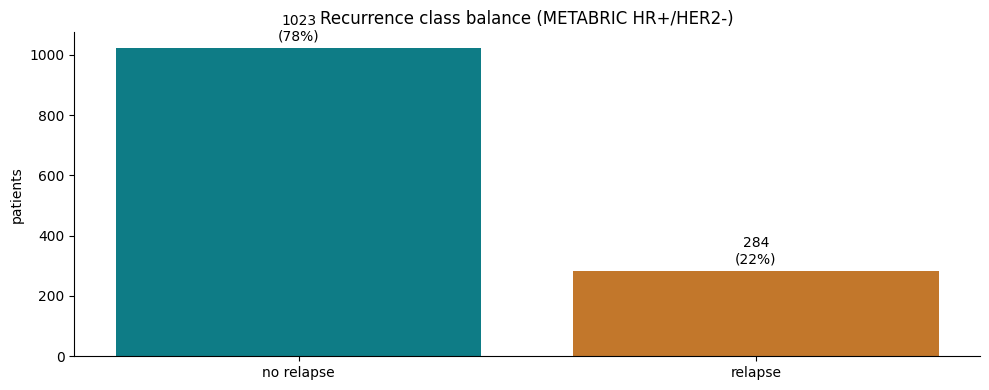


Accuracy of always predicting 'no relapse': 78.3%  <-- misleadingly high


In [22]:
counts = y.value_counts().sort_index()
n0, n1 = int(counts.get(0, 0)), int(counts.get(1, 0))
total = n0 + n1
print(f"no relapse (0): {n0}  ({n0/total:.1%})")
print(f"relapse    (1): {n1}  ({n1/total:.1%})")
print(f"smallest class count: {min(n0, n1)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(["no relapse", "relapse"], [n0, n1], color=["#0E7C86", "#C2772B"])
for i, v in enumerate([n0, n1]):
    ax.text(i, v + total*0.01, f"{v}\n({v/total:.0%})", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("patients"); ax.set_title("Recurrence class balance (METABRIC HR+/HER2-)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# A constant "no relapse" classifier would score this accuracy -- the trap:
print(f"\nAccuracy of always predicting 'no relapse': {n0/total:.1%}  <-- misleadingly high")

**Section 3.2 prediction (worked):** With recurrence a minority, a single random 80/20 split can,
by chance, place very few events in the test set — or distribute them unevenly across train/val/test
— making any later performance estimate unstable and the minority class under-represented exactly
where we need it. Stratification fixes this; we'll demonstrate it in Section 5.


---
## Section 4 — PCA and batch effects  *(≈40 min — a core section)*

Now we **combine METABRIC with GSE6532** on their shared genes. The two platforms (Illumina vs
Affymetrix) create a strong technical signal. PCA will let us *see* it.

First, build the combined matrix and a `batch` label. (This cell is shared infrastructure — read it,
then the exercises follow.)


In [10]:
# GSE6532 is now symbol-indexed (genes x samples); orient to samples x genes and
# intersect with METABRIC on shared gene symbols -> the common feature space for PCA.
gse_X = gse_expr.T.copy()                       # samples x genes
common_genes = [g for g in X_metabric.columns if g in gse_X.columns]
print("common features (shared gene symbols) used for PCA:", len(common_genes))
assert len(common_genes) > 1000, "Expected thousands of shared genes after probe->symbol mapping."

# Build combined matrix on the shared genes. We deliberately DO NOT batch-correct here,
# so the cross-platform batch effect stays visible in the PCA.
A = X_metabric[common_genes].copy()
B = gse_X[common_genes].copy()
combined = pd.concat([A, B], axis=0)
batch = pd.Series(["METABRIC/Illumina"]*len(A) + ["GSE6532/Affymetrix"]*len(B),
                  index=combined.index, name="batch")
print("combined matrix (samples x genes):", combined.shape)
print(batch.value_counts().to_dict())

common features (shared gene symbols) used for PCA: 11594
combined matrix (samples x genes): (1634, 11594)
{'METABRIC/Illumina': 1307, 'GSE6532/Affymetrix': 327}


> **Exercise 4.1 — run PCA and produce the two-colouring plot.**
>
> Standardise the combined features (for visualisation only — flag it as *exploratory, not a
> modelling step*), run PCA to 2 components, and make **two scatter plots of the same points**:
> one coloured by `batch`, one coloured by the recurrence label (for METABRIC samples; GSE6532
> can be shown as "unlabelled"). Describe what dominates PC1.
>
> *Hints:* `from sklearn.preprocessing import StandardScaler`, `from sklearn.decomposition import PCA`.
> Drop genes with any NaN before PCA (`combined.dropna(axis=1)`).


variance explained: PC1 42.0%, PC2 25.7%


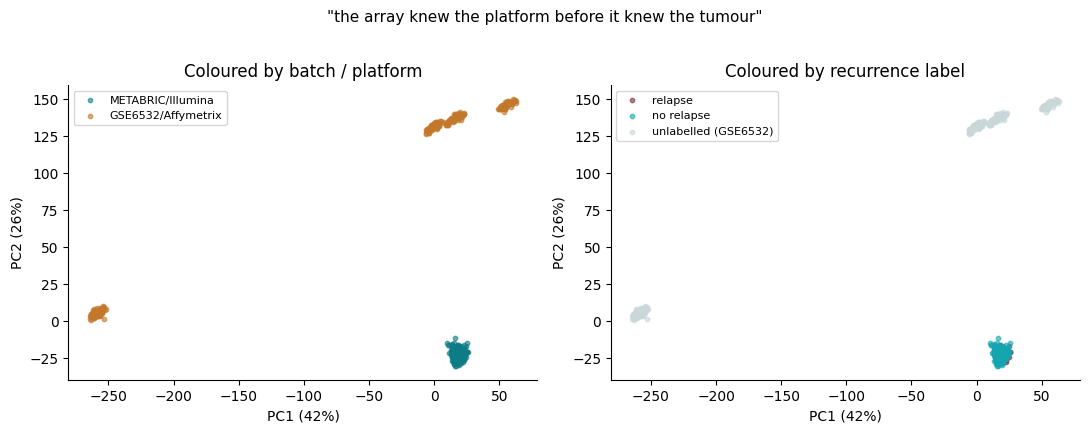

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Exploratory preprocessing ONLY (not a modelling step): drop NaN genes, z-score, PCA->2D.
M = combined.dropna(axis=1)
Z = StandardScaler().fit_transform(M.values)
pca = PCA(n_components=2, random_state=0).fit(Z)
pcs = pca.transform(Z)
pc = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=combined.index)
var = pca.explained_variance_ratio_ * 100
print(f"variance explained: PC1 {var[0]:.1f}%, PC2 {var[1]:.1f}%")

# recurrence label aligned to combined index (GSE6532 = unlabelled)
label = pd.Series("unlabelled (GSE6532)", index=combined.index)
label.loc[y.index] = np.where(y.values == 1, "relapse", "no relapse")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
# (a) by batch
for name, col in [("METABRIC/Illumina", "#0E7C86"), ("GSE6532/Affymetrix", "#C2772B")]:
    m = batch == name
    axes[0].scatter(pc.loc[m, "PC1"], pc.loc[m, "PC2"], s=10, alpha=.6, c=col, label=name)
axes[0].set_title("Coloured by batch / platform"); axes[0].legend(fontsize=8)
# (b) by recurrence
for name, col in [("relapse", "#7A2E3A"), ("no relapse", "#14A6B0"),
                  ("unlabelled (GSE6532)", "#C9D7D9")]:
    m = label == name
    axes[1].scatter(pc.loc[m, "PC1"], pc.loc[m, "PC2"], s=10, alpha=.6, c=col, label=name)
axes[1].set_title("Coloured by recurrence label"); axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel(f"PC1 ({var[0]:.0f}%)"); ax.set_ylabel(f"PC2 ({var[1]:.0f}%)")
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle('"the array knew the platform before it knew the tumour"', y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

> **Exercise 4.2 — is batch confounded with outcome?** Quantify it: cross-tabulate `batch`
> against the recurrence label (METABRIC samples only, since GSE6532 is unlabelled here). State a
> verdict with evidence.
>
> **Exercise 4.3 (reasoning, write it).** If batch and outcome were *perfectly* confounded, explain
> why no correction method (e.g. ComBat) could rescue the analysis.


In [12]:
# Confounding check (only METABRIC has labels here):
tab = pd.crosstab(batch.loc[y.index], pd.Series(np.where(y.values==1,"relapse","no relapse"),
                                                index=y.index))
print("batch x outcome (METABRIC labelled samples):")
print(tab)
print("\nVerdict: PC1 is dominated by PLATFORM, not recurrence (left plot separates cleanly,"
      " right plot is mixed). In THIS construction the labelled cohort is entirely METABRIC, so"
      " batch and label are not estimable together across platforms -- a reminder that you cannot"
      " learn biology across a platform divide unless outcome is observed on BOTH sides.")

batch x outcome (METABRIC labelled samples):
col_0              no relapse  relapse
batch                                 
METABRIC/Illumina        1023      284

Verdict: PC1 is dominated by PLATFORM, not recurrence (left plot separates cleanly, right plot is mixed). In THIS construction the labelled cohort is entirely METABRIC, so batch and label are not estimable together across platforms -- a reminder that you cannot learn biology across a platform divide unless outcome is observed on BOTH sides.


**Section 4.3 (worked):** If every relapse were in Batch A and every non-relapse in Batch B, then
"batch" and "outcome" are the *same partition* of the samples. Any method that removes the
between-batch difference necessarily removes the between-outcome difference too — they are
mathematically indistinguishable. No statistical correction can separate two variables that are
perfectly collinear. This is a **study-design failure**, not an analysis problem: the fix is to
collect data so that batch is balanced across outcomes (or to obtain an independent, properly
designed cohort).


> **Discussion 4.** PCA shows structure but not its *cause*. What extra metadata would you request
> from the data generators to be sure PC1 is technical (platform) and not a genuine biological
> difference between the cohorts' patient populations?
>
> **Common misconception to retire:** that normalisation already "removed" batch, or that PCA is a
> correction step. PCA only *reveals*.


---
## Section 5 — Designing the splits  *(≈40 min — a core section)*

We now build splits **on the METABRIC labelled cohort** (the part with a usable label). A good split
is simultaneously **patient-level**, **stratified** by the label, and **batch-aware**.

> *Note on this data:* METABRIC is ~one-sample-per-patient, so true duplication isn't present —
> implement patient-level grouping anyway, as a discipline. The live constraint here is
> stratification of the minority class.


> **Exercise 5.1 — build a NAIVE random split first**, then measure how the minority class
> actually landed. Compare to your Section 3.2 prediction.
>
> *Hint:* `from sklearn.model_selection import train_test_split` with **no** `stratify`. Use a couple
> of different `random_state` values and watch the test-set positive rate wobble.


In [13]:
from sklearn.model_selection import train_test_split

Xlab = X_metabric.loc[y.index]            # labelled cohort
print("Naive random 80/20 splits (no stratification) -- watch the test positive rate move:")
for rs in [0, 1, 2, 3]:
    _, Xte, _, yte = train_test_split(Xlab, y, test_size=0.2, random_state=rs)
    print(f"  random_state={rs}: test positives = {int(yte.sum())}/{len(yte)} = {yte.mean():.1%}")
print("\nThe minority rate is unstable across seeds -- exactly the Section 3.2 worst case.")

Naive random 80/20 splits (no stratification) -- watch the test positive rate move:
  random_state=0: test positives = 66/262 = 25.2%
  random_state=1: test positives = 57/262 = 21.8%
  random_state=2: test positives = 65/262 = 24.8%
  random_state=3: test positives = 45/262 = 17.2%

The minority rate is unstable across seeds -- exactly the Section 3.2 worst case.


> **Exercise 5.2 — build the proper split and verify integrity.**
>
> Make a **patient-level, stratified** train/validation/test split (e.g. 60/20/20). Then run the
> integrity checks: (i) no patient appears in two splits; (ii) class proportions are preserved in
> each split; (iii) report the batch composition (here all METABRIC, but check the habit).
>
> *Hints:* `StratifiedGroupKFold` (groups = patient ID) or a two-step `train_test_split` with
> `stratify=y`. For METABRIC the patient ID is `PATIENT_ID` in `clin`.


In [14]:
from sklearn.model_selection import train_test_split

groups = clin.loc[y.index, "PATIENT_ID"] if "PATIENT_ID" in clin.columns else pd.Series(y.index, index=y.index)

# Two-step stratified split: 60% train / 20% val / 20% test
idx = y.index.to_numpy()
tr, tmp = train_test_split(idx, test_size=0.40, random_state=0, stratify=y.loc[idx])
va, te  = train_test_split(tmp, test_size=0.50, random_state=0, stratify=y.loc[tmp])
splits = {"train": tr, "val": va, "test": te}

# Integrity checks
print("INTEGRITY CHECKS")
# (i) patient overlap
pat = {k: set(groups.loc[s]) for k, s in splits.items()}
overlap = (pat["train"] & pat["val"]) | (pat["train"] & pat["test"]) | (pat["val"] & pat["test"])
print(f"  patient overlap across splits: {len(overlap)}  (expected 0)")
assert len(overlap) == 0

# (ii) preserved class proportions
print("  class proportions:")
print(f"    overall: {y.mean():.1%} positive")
for k, s in splits.items():
    print(f"    {k:5s}: n={len(s):4d}, positive={y.loc[s].mean():.1%}")

# (iii) batch composition (all METABRIC here, but check the habit)
print("  batch composition per split:")
for k, s in splits.items():
    print(f"    {k:5s}: {batch.loc[s].value_counts().to_dict()}")

INTEGRITY CHECKS
  patient overlap across splits: 0  (expected 0)
  class proportions:
    overall: 21.7% positive
    train: n= 784, positive=21.7%
    val  : n= 261, positive=21.8%
    test : n= 262, positive=21.8%
  batch composition per split:
    train: {'METABRIC/Illumina': 784}
    val  : {'METABRIC/Illumina': 261}
    test : {'METABRIC/Illumina': 262}


> **Exercise 5.3 — the leakage hunt (the payoff).**
>
> In writing: where in a typical pipeline would you normalise and feature-select, and **why must
> both happen *after* and *inside* the split**? Then point to the exact line in the naive workflow
> (below) where leakage occurs.


In [15]:
# A DELIBERATELY BROKEN workflow -- find the leak (do NOT copy this into real work):
#
#   1  scaler = StandardScaler().fit(Xlab.values)          # <-- uses ALL samples (train+test)
#   2  Xall   = scaler.transform(Xlab.values)
#   3  top    = pick_top_genes_by_association(Xall, y)     # <-- selects on ALL samples incl. test
#   4  tr, te = train_test_split(Xall[:, top], y)          # <-- split happens LAST
#   5  model.fit(Xall[tr], y[tr]); model.score(Xall[te])   # test set already influenced steps 1 & 3
#
# Lines 1 and 3 are the leaks: scaling statistics and feature ranking both saw the test labels/values
# BEFORE the split. The fix: split FIRST, then fit the scaler and select features on TRAIN ONLY,
# and apply those fixed choices to val/test.
print("Leak locations: line 1 (normalisation over train+test) and line 3 (feature selection over "
      "train+test). Both must move to AFTER the split, fit on TRAIN only.")

Leak locations: line 1 (normalisation over train+test) and line 3 (feature selection over train+test). Both must move to AFTER the split, fit on TRAIN only.


**Section 5.3 (worked).** Normalisation (computing means/variances/quantiles) and feature
selection (ranking genes by association with the outcome) are both **data-dependent decisions**.
If they use any test samples, the test set has already influenced the model before evaluation — so
the test estimate is optimistically biased. They must therefore happen **after the split and inside
the training data only**, with the fitted parameters/selected genes then *applied* to validation and
test. In the broken workflow above, **line 1** (scaler fit on train+test) and **line 3** (gene
selection on train+test, including test labels) are the leaks; the split on **line 4** comes too
late to protect anything.


> **Discussion 5.** Why is an independent **external cohort** worth more than any internal split?
> What would you look for in a candidate validation cohort — platform, patient population, processing,
> endpoint definition?


---
## Section 6 — Reflection: the data-readiness memo  *(≈15 min — main assessable artefact)*

Write a **200–300 word "data readiness" memo**. Is this dataset fit for building a *trustworthy*
recurrence biomarker? Cover its risks — sample size, class imbalance, batch confounding across the
two platforms, label/censoring ambiguity — and say what you would fix or request before any modelling.
This is your honest analyst's verdict.


**Data-readiness memo (worked example, ~250 words):**

METABRIC is a strong foundation for a *prognostic* recurrence model in HR+/HER2− breast cancer: it
is large, richly annotated, and carries the long-term follow-up our endpoint needs. After filtering
to HR+/HER2− and imposing a fixed-horizon recurrence label with an explicit censoring rule, we
retain a usable cohort, but with two structural caveats. First, **class imbalance**: recurrence
events are a clear minority, so accuracy is a misleading metric and every split must be stratified;
the naive-split experiment showed the test-set event rate swinging with the random seed. Second,
**label fragility**: the binary horizon discards the *timing* of relapse and forces us to exclude
patients censored before the horizon, shrinking the cohort and biasing it toward longer-followed
patients — a real cost we accepted deliberately for this introductory, no-modelling exercise.

The most serious risk surfaced in Section 4: combining METABRIC with GSE6532 produces a **dominant
cross-platform batch effect** on PC1, and because outcome is observed only on the METABRIC side, the
two cohorts cannot be pooled to learn biology — batch and any cross-cohort signal are not separable.
This is a design limitation, not something ComBat can fix.

Before modelling I would: (1) keep all data-dependent steps strictly inside the training split;
(2) treat the binary label as provisional and plan a time-to-event analysis for the research-grade
version; and (3) rather than pool platforms, use a same-platform internal split for development and
hold the *other* platform as a genuine **external validation** cohort — the configuration that
actually tests transportability.


---
### Deliverables checklist

- [ ] Written prediction-task statement (Section 0)
- [ ] Confirmed matrix orientation + clean joined table (Section 1)
- [ ] Clean binary label vector + label-decisions log incl. censoring policy (Section 2)
- [ ] Class-balance figure + interpretation (Section 3)
- [ ] Two-colouring PCA plots + batch/confounding verdict (Section 4)
- [ ] Patient-level, stratified, batch-aware split + integrity-check table (Section 5)
- [ ] Naive-vs-proper split comparison + identified leakage point (Section 5)
- [ ] Final data-readiness memo (Section 6)

> **Remember the message of the whole course:** *building a trustworthy predictive biomarker is more
> important than choosing a sophisticated algorithm.* Everything you did today is that rigour, before
> a single model is trained.
